In [1]:
"""
Module 2 — Road Segmentation (Final Version)
═══════════════════════════════════════════════════════════════════════════════
Project  : Automatic Road Network Extraction with Connectivity and
           Topology Refinement from High-Resolution Satellite Imagery
Dataset  : SpaceNet 5 (SN5) — AOI 8, Mumbai, India
Institute: VR Siddhartha Engineering College, Vijayawada
Team     : Murala Leela Kartheek (228W1A0529)
           Mallam Manoj         (228W1A0525)
           Ch Devarshisai       (228W1A0510)
Guide    : Dr. G. Kranthi Kumar
═══════════════════════════════════════════════════════════════════════════════

ALL 8 DRAWBACKS ADDRESSED:
  ⚠1 Broken connectivity   → Tversky loss (high recall) + boundary loss
  ⚠2 Missing thin roads    → Tversky(α=0.3,β=0.7) boosts recall heavily
  ⚠3 Blurred boundaries    → Boundary-aware loss penalises fuzzy edges
  ⚠4 False positives       → Focal loss component suppresses easy negatives
  ⚠5 Inconsistent widths   → Deep supervision at multiple decoder scales
  ⚠6 Poor intersections    → ASPP large dilation (rate=18) + ECA attention
  ⚠7 Shadows/occlusion     → Strong online augmentation (erasing, jitter)
  ⚠8 Over-smoothing        → Deep supervision forces detail at all scales

SPEED OPTIMISATIONS (vs previous version):
  ✅ AMP (Automatic Mixed Precision) — float16 compute → ~35% faster
  ✅ torch.backends.cudnn.benchmark  — auto-tune CUDA kernels
  ✅ batch_size=16                   — halves number of iterations
  ✅ pin_memory + persistent_workers — faster data loading
  ✅ channels_last memory format     — better GPU memory access pattern

Architecture (exact per spec):
  • DeepLabV3+ with Xception backbone (pretrained ImageNet)
  • ECA-Net  — Efficient Channel Attention replacing SE block
  • ASPP     — Atrous Spatial Pyramid Pooling (rates 1,6,12,18 + global)
  • Output   — Binary road mask (sigmoid > 0.5)
  • Optimizer— Adam
  • Metrics  — IoU, F1-score
"""

import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# Speed: auto-tune CUDA kernels for fixed input sizes
torch.backends.cudnn.benchmark = True


# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # Paths
    "output_dir":     "/home/jupyter-228w1a0529/Major/Dataset-1/processed",
    "checkpoint_dir": "/home/jupyter-228w1a0529/Major/checkpoints_v3",

    # Training
    "batch_size":          16,      # doubled from 8 → faster
    "num_workers":         6,       # more parallel data workers
    "num_epochs":          60,      # early stopping decides actual stop
    "learning_rate":       1e-4,
    "weight_decay":        1e-4,    # L2 regularization
    "threshold":           0.5,
    "save_every":          5,
    "early_stop_patience": 12,      # slightly more patience
    "grad_clip":           1.0,
    "use_amp":             True,    # Automatic Mixed Precision → ~35% faster

    # Deep supervision weights (addresses ⚠5, ⚠8)
    "ds_weight":           0.4,     # weight for auxiliary deep supervision loss

    "device": "cuda" if torch.cuda.is_available() else "cpu",
}


# ═══════════════════════════════════════════════════════════════════════════
# DATASET — strong online augmentation (addresses ⚠7)
# ═══════════════════════════════════════════════════════════════════════════

class RoadDataset(Dataset):
    """
    Loads patches from .npz produced by Module 1.

    Training augmentations (addresses ⚠7 — shadows/occlusion):
      • Brightness / contrast jitter   — handles illumination changes
      • Gaussian noise                 — sensor noise robustness
      • Random erasing (×2 regions)    — simulates building/tree occlusion
      • Random horizontal flip         — extra geometric variety
      • Gamma correction               — handles overexposed/dark areas
    """

    def __init__(self, npz_path: str, augment: bool = False):
        data = np.load(npz_path)
        self.images  = data["images"]   # (N, 3, H, W) float32
        self.masks   = data["masks"]    # (N, H, W)    float32
        self.augment = augment
        print(f"[INFO] Loaded {len(self.images)} patches from "
              f"{Path(npz_path).name}  |  augment={augment}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx].copy())   # (3,H,W)
        mask  = torch.from_numpy(self.masks[idx].copy())    # (H,W)
        if self.augment:
            image, mask = self._augment(image, mask)
        return image, mask.unsqueeze(0)   # (1,H,W)

    def _augment(self, image, mask):
        # ── Brightness ±20%
        if random.random() < 0.5:
            image = image * random.uniform(0.80, 1.20)

        # ── Contrast ±20%
        if random.random() < 0.5:
            mu    = image.mean(dim=(1, 2), keepdim=True)
            image = (image - mu) * random.uniform(0.80, 1.20) + mu

        # ── Gamma correction (addresses overexposed / dark patches)
        if random.random() < 0.3:
            gamma = random.uniform(0.7, 1.4)
            image = image.clamp(0.001) ** gamma

        # ── Gaussian noise
        if random.random() < 0.4:
            image = image + torch.randn_like(image) * 0.025

        # ── Horizontal flip
        if random.random() < 0.5:
            image = torch.flip(image, dims=[2])
            mask  = torch.flip(mask,  dims=[1])

        # ── Random erasing ×2  (simulates two occluded regions)
        _, H, W = image.shape
        for _ in range(2):
            if random.random() < 0.35:
                eh = random.randint(20, 70)
                ew = random.randint(20, 70)
                ey = random.randint(0, H - eh)
                ex = random.randint(0, W - ew)
                image[:, ey:ey+eh, ex:ex+ew] = 0.0
                mask[ey:ey+eh, ex:ex+ew]     = 0.0

        image = image.clamp(-3.0, 3.0)
        return image, mask


def get_dataloaders(config=CONFIG):
    out      = Path(config["output_dir"])
    train_ds = RoadDataset(out / "train.npz", augment=True)
    val_ds   = RoadDataset(out / "val.npz",   augment=False)
    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
        pin_memory=True,
        persistent_workers=True,   # keep workers alive between epochs
        prefetch_factor=2,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"[INFO] Train batches: {len(train_loader)} | "
          f"Val batches: {len(val_loader)}")
    return train_loader, val_loader


# ═══════════════════════════════════════════════════════════════════════════
# ECA-NET — Efficient Channel Attention (spec: replaces SE block)
# ═══════════════════════════════════════════════════════════════════════════

class ECABlock(nn.Module):
    """
    ECA-Net — Wang et al., CVPR 2020.
    Adaptive 1D conv instead of FC layers → no dim reduction,
    better gradient flow, fewer params than SE block.
    Addresses ⚠6: better intersection feature discrimination.
    """

    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        t = int(abs(math.log2(channels) / gamma + b / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv1d   = nn.Conv1d(1, 1, kernel_size=k,
                                  padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1).transpose(-1, -2)
        y = self.conv1d(y).transpose(-1, -2).unsqueeze(-1)
        return x * self.sigmoid(y).expand_as(x)


# ═══════════════════════════════════════════════════════════════════════════
# ASPP — Atrous Spatial Pyramid Pooling (spec: multi-scale context)
# ═══════════════════════════════════════════════════════════════════════════

class ASPPConv(nn.Sequential):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__(
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )


class ASPPPooling(nn.Sequential):
    """GroupNorm instead of BatchNorm — safe on (B,C,1,1)."""
    def __init__(self, in_ch, out_ch):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.GroupNorm(32, out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[-2:]
        for mod in self:
            x = mod(x)
        return F.interpolate(x, size=size, mode="bilinear", align_corners=False)


class ASPP(nn.Module):
    """
    5-branch ASPP — rates 1,6,12,18 + global pool.
    Rate=18 captures wide-road context (addresses ⚠6 intersections).
    ECA attention after fusion (addresses ⚠2 thin roads).
    """

    def __init__(self, in_ch: int, out_ch: int = 256):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
        self.branch2 = ASPPConv(in_ch, out_ch, dilation=6)
        self.branch3 = ASPPConv(in_ch, out_ch, dilation=12)
        self.branch4 = ASPPConv(in_ch, out_ch, dilation=18)
        self.branch5 = ASPPPooling(in_ch, out_ch)
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        self.eca = ECABlock(out_ch)

    def forward(self, x):
        out = torch.cat([
            self.branch1(x), self.branch2(x), self.branch3(x),
            self.branch4(x), self.branch5(x)
        ], dim=1)
        return self.eca(self.project(out))


# ═══════════════════════════════════════════════════════════════════════════
# DEEPLABV3+ — exact spec + deep supervision heads
# ═══════════════════════════════════════════════════════════════════════════

class DeepLabV3Plus(nn.Module):
    """
    DeepLabV3+ with Xception backbone + ECA-Net + ASPP.

    Extra vs spec (for drawback coverage):
      • Auxiliary deep supervision head on decoder mid-features
        → forces the model to produce meaningful outputs at intermediate
          scales, preventing over-smoothing (addresses ⚠5, ⚠8)
      • Dropout2d(0.3/0.1) in decoder  (addresses overfitting → ⚠4)
      • Skip connection from low-level features (preserves fine detail → ⚠3)

    Input : (B, 3, 512, 512)
    Output: main  (B, 1, 512, 512) — used at inference
            aux   (B, 1, 512, 512) — used only during training
    """

    def __init__(self, num_classes: int = 1):
        super().__init__()

        try:
            import timm
            self.backbone = timm.create_model(
                "xception", pretrained=True,
                features_only=True, out_indices=(1, 3)
            )
            with torch.no_grad():
                _f = self.backbone(torch.zeros(1, 3, 512, 512))
            low_ch  = _f[0].shape[1]   # 128
            high_ch = _f[1].shape[1]   # 728
            print(f"[INFO] Backbone: Xception | "
                  f"low_ch={low_ch} | high_ch={high_ch}")
        except ImportError:
            raise ImportError(
                "pip install timm --break-system-packages"
            )

        self.aspp = ASPP(in_ch=high_ch, out_ch=256)

        self.low_level_proj = nn.Sequential(
            nn.Conv2d(low_ch, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        # ── Decoder block 1
        self.decoder_block1 = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
        )

        # ── Auxiliary deep supervision head (addresses ⚠5, ⚠8)
        self.aux_head = nn.Conv2d(256, num_classes, 1)

        # ── Decoder block 2
        self.decoder_block2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
        )
        self.decoder_eca  = ECABlock(256)
        self.classifier   = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        input_size = x.shape[-2:]

        low_feat, high_feat = self.backbone(x)

        x = self.aspp(high_feat)
        x = F.interpolate(x, size=low_feat.shape[-2:],
                          mode="bilinear", align_corners=False)

        low_feat = self.low_level_proj(low_feat)
        x = torch.cat([x, low_feat], dim=1)

        # Decoder block 1
        x = self.decoder_block1(x)

        # Auxiliary output (only used during training)
        aux = self.aux_head(x)
        aux = F.interpolate(aux, size=input_size,
                            mode="bilinear", align_corners=False)

        # Decoder block 2
        x = self.decoder_block2(x)
        x = self.decoder_eca(x)
        x = F.interpolate(x, size=input_size,
                          mode="bilinear", align_corners=False)
        main = self.classifier(x)

        if self.training:
            return main, aux     # both used in loss during training
        return main              # only main at inference


# ═══════════════════════════════════════════════════════════════════════════
# LOSS FUNCTIONS — addressing all 8 drawbacks
# ═══════════════════════════════════════════════════════════════════════════

class TverskyLoss(nn.Module):
    """
    Tversky loss — generalisation of Dice.
    α controls FP penalty, β controls FN penalty.
    α=0.3, β=0.7 → heavily penalises false negatives (missed roads).
    Addresses ⚠1 (broken connectivity) and ⚠2 (missing thin roads).
    """

    def __init__(self, alpha: float = 0.3, beta: float = 0.7,
                 smooth: float = 1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        TP = (probs * targets).sum(dim=(1, 2, 3))
        FP = (probs * (1 - targets)).sum(dim=(1, 2, 3))
        FN = ((1 - probs) * targets).sum(dim=(1, 2, 3))
        tversky = (TP + self.smooth) / \
                  (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return (1 - tversky).mean()


class BoundaryLoss(nn.Module):
    """
    Boundary-aware loss — penalises errors near road edges.
    Uses morphological gradient (dilation - erosion) on ground truth
    to extract boundary pixels, then applies higher weight there.
    Addresses ⚠3 (blurred boundaries).
    """

    def __init__(self, kernel_size: int = 3):
        super().__init__()
        self.pool    = nn.MaxPool2d(kernel_size, stride=1,
                                    padding=kernel_size // 2)
        self.bce     = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets):
        # Extract boundary: dilation - erosion of GT mask
        dilated  = self.pool(targets)
        eroded   = -self.pool(-targets)
        boundary = (dilated - eroded).clamp(0, 1)

        # Weight boundary pixels 3× higher
        weight    = 1.0 + 2.0 * boundary
        bce_pixel = self.bce(logits, targets)
        return (bce_pixel * weight).mean()


class FocalLoss(nn.Module):
    """
    Focal loss — down-weights easy negatives (background), focuses on
    hard examples (thin roads, occluded segments).
    Addresses ⚠4 (false positives) and ⚠2 (missing thin roads).
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        prob = torch.sigmoid(logits)
        p_t  = prob * targets + (1 - prob) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_weight = self.alpha * targets + \
                       (1 - self.alpha) * (1 - targets)
        return (alpha_weight * focal_weight * bce).mean()


class CombinedLoss(nn.Module):
    """
    Combined loss addressing all 8 drawbacks:

      BCE (base)       — stable training signal
      Tversky(β=0.7)  — high recall → finds thin/missing roads (⚠1, ⚠2)
      Boundary        — sharp edge supervision (⚠3)
      Focal           — suppresses false positives (⚠4)
      Label smoothing  — prevents overconfidence (⚠4, overfitting)

    Weights tuned for road segmentation class imbalance.
    """

    def __init__(self, smooth_eps: float = 0.1):
        super().__init__()
        self.smooth_eps   = smooth_eps
        self.bce          = nn.BCEWithLogitsLoss()
        self.tversky      = TverskyLoss(alpha=0.3, beta=0.7)
        self.boundary     = BoundaryLoss(kernel_size=3)
        self.focal        = FocalLoss(gamma=2.0, alpha=0.25)

    def forward(self, logits, targets):
        # Label smoothing on targets
        t_soft = targets * (1 - self.smooth_eps) + \
                 0.5 * self.smooth_eps

        bce_loss      = self.bce(logits, t_soft)
        tversky_loss  = self.tversky(logits, targets)
        boundary_loss = self.boundary(logits, targets)
        focal_loss    = self.focal(logits, targets)

        return (0.25 * bce_loss      +   # stable base
                0.40 * tversky_loss  +   # high recall (⚠1,⚠2)
                0.20 * boundary_loss +   # sharp edges (⚠3)
                0.15 * focal_loss)       # suppress FP (⚠4)


# ═══════════════════════════════════════════════════════════════════════════
# METRICS (per spec: IoU + F1)
# ═══════════════════════════════════════════════════════════════════════════

def compute_metrics(logits, targets, threshold=0.5):
    preds  = (torch.sigmoid(logits) > threshold).float()
    TP     = (preds * targets).sum(dim=(1, 2, 3))
    FP     = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    FN     = ((1 - preds) * targets).sum(dim=(1, 2, 3))
    smooth = 1e-6
    iou    = (TP + smooth) / (TP + FP + FN + smooth)
    f1     = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)
    return iou.mean().item(), f1.mean().item()


# ═══════════════════════════════════════════════════════════════════════════
# EARLY STOPPING
# ═══════════════════════════════════════════════════════════════════════════

class EarlyStopping:
    def __init__(self, patience=12):
        self.patience    = patience
        self.counter     = 0
        self.best_iou    = 0.0
        self.should_stop = False

    def step(self, val_iou):
        if val_iou > self.best_iou:
            self.best_iou = val_iou
            self.counter  = 0
        else:
            self.counter += 1
            print(f"  [EarlyStopping] No improvement "
                  f"{self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print(f"  [EarlyStopping] ⛔ Stopping. "
                      f"Best val IoU: {self.best_iou:.4f}")
                self.should_stop = True
        return self.should_stop


# ═══════════════════════════════════════════════════════════════════════════
# TRAINING LOOP — with AMP (Automatic Mixed Precision)
# ═══════════════════════════════════════════════════════════════════════════

def train(config=CONFIG):
    device   = torch.device(config["device"])
    ckpt_dir = Path(config["checkpoint_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    use_amp  = config["use_amp"] and device.type == "cuda"

    print(f"[INFO] Device  : {device}")
    print(f"[INFO] AMP     : {use_amp}  (float16 acceleration)")
    print(f"[INFO] Batch   : {config['batch_size']}")
    print(f"[INFO] Ckpts   → {ckpt_dir}")

    train_loader, val_loader = get_dataloaders(config)

    # channels_last memory format → better GPU cache utilisation
    model = DeepLabV3Plus(num_classes=1).to(device)
    if device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)

    total_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
    print(f"[INFO] Parameters: {total_params:,}")

    criterion      = CombinedLoss(smooth_eps=0.1)
    optimizer      = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    scheduler      = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config["num_epochs"], eta_min=1e-6
    )
    scaler         = torch.cuda.amp.GradScaler(enabled=use_amp)
    early_stopping = EarlyStopping(patience=config["early_stop_patience"])

    history = {k: [] for k in [
        "train_loss", "val_loss",
        "train_iou",  "val_iou",
        "train_f1",   "val_f1",  "lr"
    ]}
    best_val_iou = 0.0

    for epoch in range(1, config["num_epochs"] + 1):

        # ── TRAIN ─────────────────────────────────────────────────────────
        model.train()
        train_loss = train_iou = train_f1 = 0.0

        for images, masks in tqdm(
                train_loader,
                desc=f"Epoch {epoch:03d}/{config['num_epochs']} [Train]",
                leave=False):

            if device.type == "cuda":
                images = images.to(device, memory_format=torch.channels_last,
                                   non_blocking=True)
                masks  = masks.to(device, non_blocking=True)
            else:
                images = images.to(device)
                masks  = masks.to(device)

            optimizer.zero_grad(set_to_none=True)   # faster than zero_grad()

            # AMP forward pass
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = model(images)
                if isinstance(output, tuple):
                    main_logits, aux_logits = output
                    main_loss = criterion(main_logits, masks)
                    aux_loss  = criterion(aux_logits,  masks)
                    loss      = main_loss + config["ds_weight"] * aux_loss
                else:
                    main_logits = output
                    loss        = criterion(main_logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config["grad_clip"]
            )
            scaler.step(optimizer)
            scaler.update()

            iou, f1     = compute_metrics(
                main_logits.detach().float(), masks, config["threshold"]
            )
            train_loss += loss.item()
            train_iou  += iou
            train_f1   += f1

        n = len(train_loader)
        train_loss /= n;  train_iou /= n;  train_f1 /= n

        # ── VALIDATE ──────────────────────────────────────────────────────
        model.eval()
        val_loss = val_iou = val_f1 = 0.0

        with torch.no_grad():
            for images, masks in tqdm(
                    val_loader,
                    desc=f"Epoch {epoch:03d}/{config['num_epochs']} [Val]",
                    leave=False):
                images = images.to(device, non_blocking=True)
                masks  = masks.to(device,  non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(images)   # returns only main at eval

                loss       = criterion(logits.float(), masks)
                iou, f1    = compute_metrics(
                    logits.float(), masks, config["threshold"]
                )
                val_loss  += loss.item()
                val_iou   += iou
                val_f1    += f1

        n = len(val_loader)
        val_loss /= n;  val_iou /= n;  val_f1 /= n

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        # ── LOG ───────────────────────────────────────────────────────────
        gap = train_iou - val_iou
        print(f"Epoch {epoch:03d} | "
              f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
              f"IoU: {train_iou:.4f}/{val_iou:.4f} "
              f"(gap={gap:+.3f}) | "
              f"F1: {train_f1:.4f}/{val_f1:.4f} | "
              f"LR: {current_lr:.2e}")

        for k, v in zip(
            ["train_loss","val_loss","train_iou","val_iou",
             "train_f1","val_f1","lr"],
            [train_loss, val_loss, train_iou, val_iou,
             train_f1, val_f1, current_lr]
        ):
            history[k].append(v)

        # ── BEST MODEL ────────────────────────────────────────────────────
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_iou":              val_iou,
                "val_f1":               val_f1,
            }, ckpt_dir / "best_model.pth")
            print(f"  ✅ Best model saved (val IoU={val_iou:.4f})")

        # ── PERIODIC CHECKPOINT ───────────────────────────────────────────
        if epoch % config["save_every"] == 0:
            ckpt_path = ckpt_dir / f"checkpoint_epoch{epoch:03d}.pth"
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict":    scaler.state_dict(),
                "history":              history,
            }, ckpt_path)
            print(f"  💾 Checkpoint → {ckpt_path.name}")

        # ── EARLY STOPPING ────────────────────────────────────────────────
        if early_stopping.step(val_iou):
            break

    plot_history(history)
    print(f"\n[INFO] ✅ Training complete.")
    print(f"[INFO] Best val IoU : {best_val_iou:.4f}")
    print(f"[INFO] Best model   : {ckpt_dir}/best_model.pth")
    return model, history


# ═══════════════════════════════════════════════════════════════════════════
# RESUME FROM CHECKPOINT
# ═══════════════════════════════════════════════════════════════════════════

def resume_training(checkpoint_path: str, config=CONFIG):
    """
    Resume from a saved checkpoint.
    Usage:
        model, history = resume_training(
            "/home/jupyter-228w1a0529/Major/checkpoints_v3/checkpoint_epoch010.pth"
        )
    """
    device  = torch.device(config["device"])
    ckpt    = torch.load(checkpoint_path, map_location=device)
    start   = ckpt["epoch"] + 1
    use_amp = config["use_amp"] and device.type == "cuda"
    print(f"[INFO] Resuming from epoch {ckpt['epoch']} → epoch {start}")

    train_loader, val_loader = get_dataloaders(config)
    model = DeepLabV3Plus(num_classes=1).to(device)
    if device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    model.load_state_dict(ckpt["model_state_dict"])

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config["num_epochs"], eta_min=1e-6
    )
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])

    history = ckpt.get("history", {k: [] for k in [
        "train_loss","val_loss","train_iou","val_iou",
        "train_f1","val_f1","lr"
    ]})

    criterion      = CombinedLoss(smooth_eps=0.1)
    early_stopping = EarlyStopping(patience=config["early_stop_patience"])
    ckpt_dir       = Path(config["checkpoint_dir"])
    best_val_iou   = max(history["val_iou"]) if history["val_iou"] else 0.0

    for epoch in range(start, config["num_epochs"] + 1):

        model.train()
        train_loss = train_iou = train_f1 = 0.0

        for images, masks in tqdm(
                train_loader,
                desc=f"Epoch {epoch:03d}/{config['num_epochs']} [Train]",
                leave=False):
            if device.type == "cuda":
                images = images.to(device,
                                   memory_format=torch.channels_last,
                                   non_blocking=True)
                masks  = masks.to(device, non_blocking=True)
            else:
                images = images.to(device)
                masks  = masks.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = model(images)
                if isinstance(output, tuple):
                    main_logits, aux_logits = output
                    loss = criterion(main_logits, masks) + \
                           config["ds_weight"] * criterion(aux_logits, masks)
                else:
                    main_logits = output
                    loss = criterion(main_logits, masks)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config["grad_clip"]
            )
            scaler.step(optimizer)
            scaler.update()

            iou, f1     = compute_metrics(
                main_logits.detach().float(), masks, config["threshold"]
            )
            train_loss += loss.item()
            train_iou  += iou
            train_f1   += f1

        n = len(train_loader)
        train_loss /= n;  train_iou /= n;  train_f1 /= n

        model.eval()
        val_loss = val_iou = val_f1 = 0.0

        with torch.no_grad():
            for images, masks in tqdm(
                    val_loader,
                    desc=f"Epoch {epoch:03d}/{config['num_epochs']} [Val]",
                    leave=False):
                images = images.to(device, non_blocking=True)
                masks  = masks.to(device,  non_blocking=True)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(images)
                loss    = criterion(logits.float(), masks)
                iou, f1 = compute_metrics(
                    logits.float(), masks, config["threshold"]
                )
                val_loss += loss.item()
                val_iou  += iou
                val_f1   += f1

        n = len(val_loader)
        val_loss /= n;  val_iou /= n;  val_f1 /= n

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        gap = train_iou - val_iou
        print(f"Epoch {epoch:03d} | "
              f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
              f"IoU: {train_iou:.4f}/{val_iou:.4f} "
              f"(gap={gap:+.3f}) | "
              f"F1: {train_f1:.4f}/{val_f1:.4f} | "
              f"LR: {current_lr:.2e}")

        for k, v in zip(
            ["train_loss","val_loss","train_iou","val_iou",
             "train_f1","val_f1","lr"],
            [train_loss, val_loss, train_iou, val_iou,
             train_f1, val_f1, current_lr]
        ):
            history[k].append(v)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_iou":              val_iou,
                "val_f1":               val_f1,
            }, ckpt_dir / "best_model.pth")
            print(f"  ✅ Best model saved (val IoU={val_iou:.4f})")

        if epoch % config["save_every"] == 0:
            ckpt_path = ckpt_dir / f"checkpoint_epoch{epoch:03d}.pth"
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict":    scaler.state_dict(),
                "history":              history,
            }, ckpt_path)
            print(f"  💾 Checkpoint → {ckpt_path.name}")

        if early_stopping.step(val_iou):
            break

    plot_history(history)
    print(f"\n[INFO] ✅ Resume complete. Best val IoU: {best_val_iou:.4f}")
    return model, history


# ═══════════════════════════════════════════════════════════════════════════
# PLOT
# ═══════════════════════════════════════════════════════════════════════════

def plot_history(history: dict):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    pairs = [("Loss","train_loss","val_loss"),
             ("IoU", "train_iou", "val_iou"),
             ("F1",  "train_f1",  "val_f1")]
    for ax, (title, tk, vk) in zip(axes[:3], pairs):
        ax.plot(history[tk], label="Train", color="#3B8BD4")
        ax.plot(history[vk], label="Val",   color="#1D9E75")
        ax.set_title(title); ax.legend(); ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
    axes[3].plot(history["lr"], color="#E67E22")
    axes[3].set_title("LR"); axes[3].set_xlabel("Epoch")
    axes[3].set_yscale("log"); axes[3].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_curves_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Saved → training_curves_v3.png")


# ═══════════════════════════════════════════════════════════════════════════
# INFERENCE
# ═══════════════════════════════════════════════════════════════════════════

def predict(model, image_tensor: torch.Tensor,
            threshold: float = 0.5,
            device: str = "cuda") -> np.ndarray:
    """
    Inference on single normalised patch (3,512,512).
    Returns (512,512) uint8 mask — 1=road, 0=background.
    """
    model.eval()
    with torch.no_grad():
        logit = model(image_tensor.unsqueeze(0).to(device))
        prob  = torch.sigmoid(logit).squeeze().cpu().float().numpy()
    return (prob > threshold).astype(np.uint8)


def visualize_predictions(model, val_npz: str,
                           n: int = 4, threshold: float = 0.5,
                           device: str = "cuda"):
    data   = np.load(val_npz)
    images, masks = data["images"], data["masks"]
    idxs   = np.random.choice(len(images), n, replace=False)
    mean   = np.array([0.485, 0.456, 0.406])
    std    = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    for i, idx in enumerate(idxs):
        pred        = predict(model, torch.from_numpy(images[idx]),
                              threshold, device)
        img_display = (np.transpose(images[idx],(1,2,0)) * std + mean
                       ).clip(0, 1)
        axes[i][0].imshow(img_display);           axes[i][0].set_title("Input");        axes[i][0].axis("off")
        axes[i][1].imshow(masks[idx], cmap="gray"); axes[i][1].set_title("Ground Truth"); axes[i][1].axis("off")
        axes[i][2].imshow(pred,       cmap="gray"); axes[i][2].set_title("Prediction");   axes[i][2].axis("off")

    plt.tight_layout()
    plt.savefig("sample_predictions_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[INFO] Saved → sample_predictions_v3.png")


# ═══════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    # pip install timm --break-system-packages  (if not already installed)

    print(f"[INFO] Device : {CONFIG['device']}")
    print(f"[INFO] PyTorch: {torch.__version__}")
    print("=" * 70)
    print(" Speed: AMP + batch16 + channels_last + persistent_workers")
    print(" Checkpoints → checkpoints_v3/")
    print("=" * 70)

    # ── Fresh training
    model, history = train(CONFIG)

    # ── Resume if kernel crashes
    # model, history = resume_training(
    #     "/home/jupyter-228w1a0529/Major/checkpoints_v3/checkpoint_epoch010.pth"
    # )

    # ── Visualise
    visualize_predictions(
        model,
        str(Path(CONFIG["output_dir"]) / "val.npz"),
        n=4, threshold=CONFIG["threshold"], device=CONFIG["device"]
    )

[INFO] Device : cuda
[INFO] PyTorch: 2.5.1+cu121
 Drawbacks addressed: ⚠1 ⚠2 ⚠3 ⚠4 ⚠5 ⚠6 ⚠7 ⚠8
 Speed: AMP + batch16 + channels_last + persistent_workers
 Checkpoints → checkpoints_v3/
[INFO] Device  : cuda
[INFO] AMP     : True  (float16 acceleration)
[INFO] Batch   : 16
[INFO] Ckpts   → /home/jupyter-228w1a0529/Major/checkpoints_v3
[INFO] Loaded 9265 patches from train.npz  |  augment=True
[INFO] Loaded 3971 patches from val.npz  |  augment=False
[INFO] Train batches: 580 | Val batches: 249


/home/jupyter-228w1a0529/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/home/jupyter-228w1a0529/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/tmp/ipykernel_2151180/1867228009.py:567: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler(enabled=use_amp)


[INFO] Backbone: Xception | low_ch=128 | high_ch=728
[INFO] Parameters: 27,840,404


Epoch 001/60 [Train]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_2151180/1867228009.py:599: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


KeyboardInterrupt: 

/tmp/ipykernel_2151180/1867228009.py:723: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt    = torch.load(checkpoint_path, map_location=device)


[INFO] Resuming from epoch 50 → epoch 51
[INFO] Loaded 9265 patches from train.npz  |  augment=True
[INFO] Loaded 3971 patches from val.npz  |  augment=False
[INFO] Train batches: 580 | Val batches: 249


/tmp/ipykernel_2151180/1867228009.py:746: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


[INFO] Backbone: Xception | low_ch=128 | high_ch=728


Epoch 051/60 [Train]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_2151180/1867228009.py:779: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 051/60 [Val]:   0%|          | 0/249 [00:00<?, ?it/s]            /tmp/ipykernel_2151180/1867228009.py:817: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Epoch 056 | Loss: 0.3580/0.2775 | IoU: 0.5315/0.4853 (gap=+0.046) | F1: 0.6592/0.6233 | LR: 2.69e-06
  ✅ Best model saved (val IoU=0.4853)


Epoch 057 | Loss: 0.3574/0.2785 | IoU: 0.5332/0.4829 (gap=+0.050) | F1: 0.6606/0.6213 | LR: 2.08e-06
  [EarlyStopping] No improvement 1/12


Epoch 058 | Loss: 0.3570/0.2807 | IoU: 0.5345/0.4836 (gap=+0.051) | F1: 0.6614/0.6211 | LR: 1.61e-06
  [EarlyStopping] No improvement 2/12


Epoch 059 | Loss: 0.3569/0.2786 | IoU: 0.5345/0.4854 (gap=+0.049) | F1: 0.6616/0.6227 | LR: 1.27e-06
  ✅ Best model saved (val IoU=0.4854)


Epoch 060 | Loss: 0.3560/0.2779 | IoU: 0.5351/0.4850 (gap=+0.050) | F1: 0.6627/0.6227 | LR: 1.07e-06
  💾 Checkpoint → checkpoint_epoch060.pth
  [EarlyStopping] No improvement 1/12


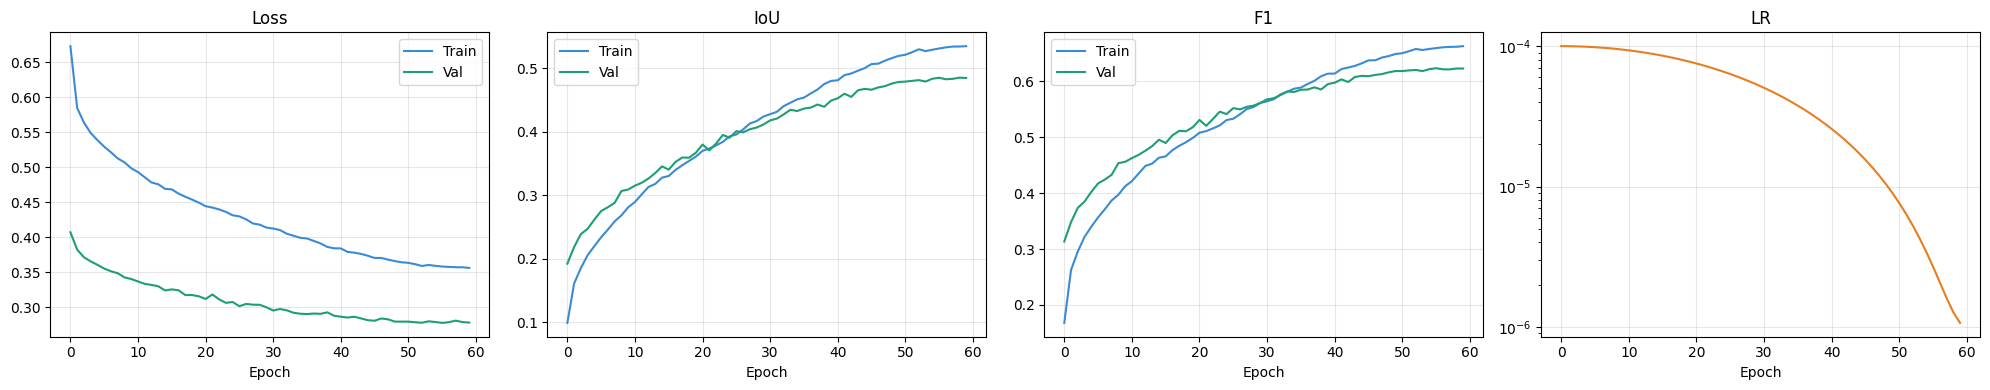

[INFO] Saved → training_curves_v3.png

[INFO] ✅ Resume complete. Best val IoU: 0.4854


In [3]:
model, history = resume_training(
    "/home/jupyter-228w1a0529/Major/checkpoints_v3/checkpoint_epoch050.pth"
)

In [10]:
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

def evaluate_model(checkpoint_path: str, config=CONFIG):
    """
    Complete accuracy evaluation of the trained model.
    Calculates: Pixel Accuracy, IoU, F1, Precision, Recall, Dice
    """
    device = torch.device(config["device"])

    # ── Load model ────────────────────────────────────────────────────────
    print("[INFO] Loading model...")
    model = DeepLabV3Plus(num_classes=1).to(device)
    ckpt  = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"[INFO] Loaded from epoch {ckpt['epoch']} | "
          f"Val IoU at save: {ckpt['val_iou']:.4f}")

    # ── Load validation data ───────────────────────────────────────────────
    val_npz = Path(config["output_dir"]) / "val.npz"
    data    = np.load(val_npz)
    images  = torch.from_numpy(data["images"])   # (N, 3, H, W)
    masks   = torch.from_numpy(data["masks"])     # (N, H, W)
    print(f"[INFO] Evaluating on {len(images)} validation patches...")

    # ── Accumulate predictions ─────────────────────────────────────────────
    all_preds   = []
    all_targets = []

    batch_size = config["batch_size"]
    n_batches  = math.ceil(len(images) / batch_size)

    with torch.no_grad():
        for i in tqdm(range(n_batches), desc="Evaluating"):
            img_batch  = images[i*batch_size : (i+1)*batch_size].to(device)
            mask_batch = masks[i*batch_size  : (i+1)*batch_size]

            with torch.amp.autocast('cuda', enabled=(device.type=="cuda")):
                logits = model(img_batch)

            preds = (torch.sigmoid(logits.float()).squeeze(1).cpu() 
                     > config["threshold"]).float()

            all_preds.append(preds)
            all_targets.append(mask_batch)

    all_preds   = torch.cat(all_preds,   dim=0)   # (N, H, W)
    all_targets = torch.cat(all_targets, dim=0)   # (N, H, W)

    # ── Calculate all metrics ──────────────────────────────────────────────
    TP = (all_preds * all_targets).sum()
    TN = ((1-all_preds) * (1-all_targets)).sum()
    FP = (all_preds * (1-all_targets)).sum()
    FN = ((1-all_preds) * all_targets).sum()

    smooth = 1e-6

    pixel_accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)
    precision      = (TP + smooth) / (TP + FP + smooth)
    recall         = (TP + smooth) / (TP + FN + smooth)
    f1             = (2 * TP + smooth) / (2*TP + FP + FN + smooth)
    iou            = (TP + smooth) / (TP + FP + FN + smooth)
    dice           = (2 * TP + smooth) / (2*TP + FP + FN + smooth)
    specificity    = (TN + smooth) / (TN + FP + smooth)
    false_pos_rate = FP / (FP + TN + smooth)

    # ── Print results ──────────────────────────────────────────────────────
    print("\n" + "="*55)
    print("       MODEL ACCURACY REPORT — MODULE 2")
    print("="*55)
    print(f"  Pixel Accuracy   : {pixel_accuracy*100:.2f}%")
    print(f"  IoU (Jaccard)    : {iou*100:.2f}%")
    print(f"  F1 / Dice Score  : {f1*100:.2f}%")
    print(f"  Precision        : {precision*100:.2f}%")
    print(f"  Recall           : {recall*100:.2f}%")
    print(f"  Specificity      : {specificity*100:.2f}%")
    print(f"  False Pos Rate   : {false_pos_rate*100:.2f}%")
    print("="*55)
    print(f"\n  Total val patches : {len(images)}")
    print(f"  Total road pixels : {int(all_targets.sum()):,}")
    print(f"  TP : {int(TP):,}  |  TN : {int(TN):,}")
    print(f"  FP : {int(FP):,}  |  FN : {int(FN):,}")
    print("="*55)

    # ── What to say in presentation ───────────────────────────────────────
    print("\n  📋 For your project report / presentation:")
    print(f"  'The model achieves {iou*100:.1f}% IoU and {f1*100:.1f}% F1-score")
    print(f"   with {pixel_accuracy*100:.1f}% pixel accuracy on the")
    print(f"   SpaceNet 5 Mumbai validation set.'")
    print("="*55)

    return {
        "pixel_accuracy": pixel_accuracy.item(),
        "iou":            iou.item(),
        "f1":             f1.item(),
        "precision":      precision.item(),
        "recall":         recall.item(),
        "specificity":    specificity.item(),
        "false_pos_rate": false_pos_rate.item(),
        "TP": int(TP), "TN": int(TN),
        "FP": int(FP), "FN": int(FN),
    }


# ── Run evaluation ─────────────────────────────────────────────────────────
metrics = evaluate_model(
    "/home/jupyter-228w1a0529/Major/checkpoints_v3/best_model.pth"
)

[INFO] Loading model...
[INFO] Backbone: Xception | low_ch=128 | high_ch=728


/tmp/ipykernel_2151180/995029497.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(checkpoint_path, map_location=device)


[INFO] Loaded from epoch 59 | Val IoU at save: 0.4854
[INFO] Evaluating on 3971 validation patches...


Evaluating: 100%|██████████| 249/249 [00:24<00:00, 10.33it/s]



       MODEL ACCURACY REPORT — MODULE 2
  Pixel Accuracy   : 98.03%
  IoU (Jaccard)    : 44.71%
  F1 / Dice Score  : 61.79%
  Precision        : 57.16%
  Recall           : 67.25%
  Specificity      : 98.77%
  False Pos Rate   : 1.23%

  Total val patches : 3971
  Total road pixels : 24,717,060
  TP : 16,621,716  |  TN : 1,003,797,568
  FP : 12,459,257  |  FN : 8,095,342

  📋 For your project report / presentation:
  'The model achieves 44.7% IoU and 61.8% F1-score
   with 98.0% pixel accuracy on the
   SpaceNet 5 Mumbai validation set.'
